In [33]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

In [34]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
rfm = pd.read_csv("customer_features.csv")

Saving customer_features (1).csv to customer_features (1).csv


In [35]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "TotalQuantity",
    "Country"
]

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(rfm[features])

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

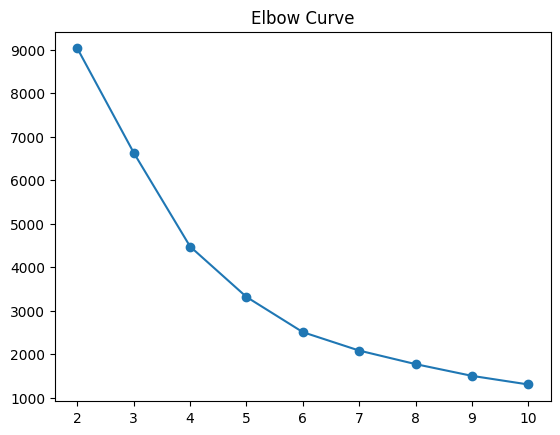

In [38]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.plot(range(2,11), inertia, marker="o")
plt.title("Elbow Curve")
plt.show()

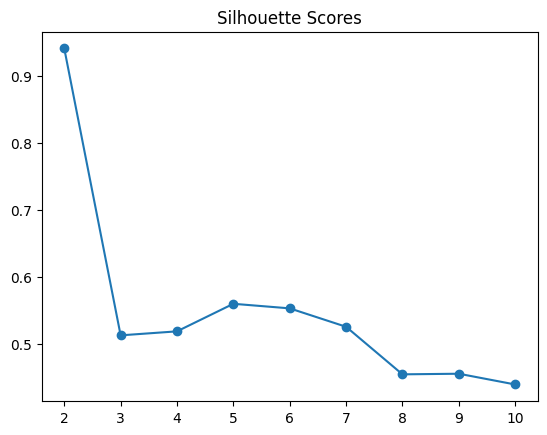

In [39]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))

plt.plot(range(2,11), scores, marker="o")
plt.title("Silhouette Scores")
plt.show()

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_pca)

In [41]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.6, min_samples=8)

rfm["DBSCAN"] = db.fit_predict(X_pca)

In [42]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)

rfm["Agglomerative"] = agg.fit_predict(X_pca)

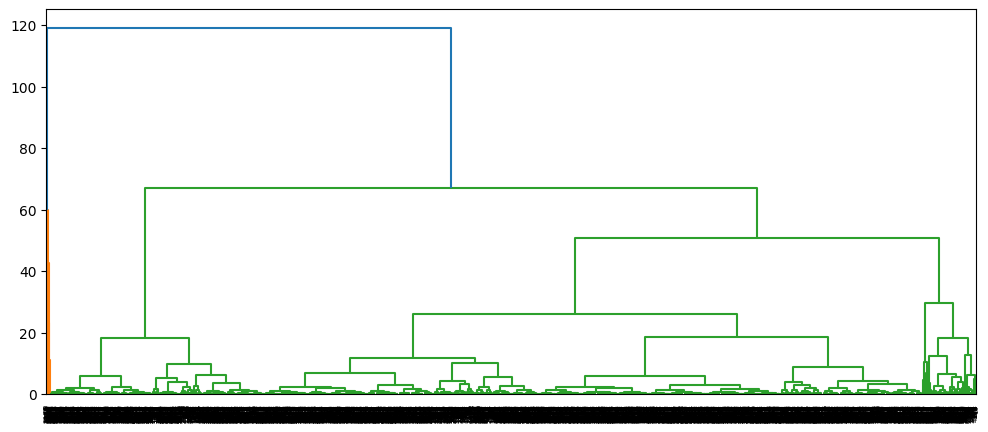

In [43]:
from scipy.cluster.hierarchy import linkage, dendrogram

link = linkage(X_pca, method="ward")

plt.figure(figsize=(12,5))
dendrogram(link)
plt.show()

In [44]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

results = []

models = {
    "KMeans": rfm["Cluster"],
    "DBSCAN": rfm["DBSCAN"],
    "Agglomerative": rfm["Agglomerative"]
}

for name, labels in models.items():

    mask = labels != -1

    if len(set(labels[mask])) > 1:

        results.append({
            "Algorithm": name,
            "Silhouette": silhouette_score(X_pca[mask], labels[mask]),
            "Davies_Bouldin": davies_bouldin_score(X_pca[mask], labels[mask]),
            "Calinski_Harabasz": calinski_harabasz_score(X_pca[mask], labels[mask])
        })

pd.DataFrame(results)

,Algorithm,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,KMeans,0.518442,0.682325,3764.294217
1,DBSCAN,0.720950,0.256103,185.785195
2,Agglomerative,0.510330,0.540518,3246.458359


In [45]:
profile = rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean",
    "AvgOrderValue":"mean",
    "TotalQuantity":"mean"
})

profile

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity
Cluster,,,,,
0,221.412943,1.556240,655.801557,403.182007,346.230354
1,109.666667,25.333333,175287.373333,55086.096210,117375.666667
2,37.627899,4.999669,1956.010515,363.030441,1151.457256
3,7.315789,70.894737,85846.085789,1796.260968,46904.210526


In [46]:
from sklearn.cluster import KMeans

# Use the optimal K found earlier
best_k = 4   # Replace with your optimal value

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_pca)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,Country,AvgOrderValue,Cluster,DBSCAN,Agglomerative
0,12346.0,326,1,77183.60,74215,35,77183.600000,1,-1,3
1,12347.0,2,7,4310.00,2458,16,615.714286,2,0,0
2,12348.0,75,4,1797.24,2341,12,449.310000,0,0,0
3,12349.0,19,1,1757.55,631,18,1757.550000,0,0,0
4,12350.0,310,1,334.40,197,24,334.400000,0,0,2


In [47]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

results = []

algorithms = {
    "K-Means": rfm["Cluster"],
    "DBSCAN": DBSCAN(eps=0.6, min_samples=8).fit_predict(X_pca),
    "Agglomerative": AgglomerativeClustering(n_clusters=best_k).fit_predict(X_pca)
}

for name, labels in algorithms.items():

    mask = labels != -1

    if len(set(labels[mask])) > 1:
        results.append({
            "Algorithm": name,
            "Silhouette Score": round(silhouette_score(X_pca[mask], labels[mask]),3),
            "Davies-Bouldin": round(davies_bouldin_score(X_pca[mask], labels[mask]),3),
            "Calinski-Harabasz": round(calinski_harabasz_score(X_pca[mask], labels[mask]),2)
        })

evaluation_df = pd.DataFrame(results)
evaluation_df

,Algorithm,Silhouette Score,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.518,0.682,3764.29
1,DBSCAN,0.721,0.256,185.79
2,Agglomerative,0.510,0.541,3246.46


In [ ]:
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean",
    "AvgOrderValue":"mean",
    "TotalQuantity":"mean"
}).round(2)

cluster_profile

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity
Cluster,,,,,
0,221.41,1.56,655.80,403.18,346.23
1,109.67,25.33,175287.37,55086.10,117375.67
2,37.63,5.00,1956.01,363.03,1151.46
3,7.32,70.89,85846.09,1796.26,46904.21


In [64]:
# Create cluster profile
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "AvgOrderValue": "mean",
    "TotalQuantity": "mean"
}).round(2)

# Sort clusters by Monetary (highest first), then Frequency
sorted_clusters = cluster_profile.sort_values(
    ["Monetary", "Frequency"],
    ascending=[False, False]
).index.tolist()

# Assign one unique name to each cluster
segment_names = {
    sorted_clusters[0]: "High Value Loyal",
    sorted_clusters[1]: "Frequent Buyer",
    sorted_clusters[2]: "Occasional Customer",
    sorted_clusters[3]: "At Risk"
}

# Map segment names
rfm["Segment_Name"] = rfm["Cluster"].map(segment_names)

# Verify that all 4 segments exist
print(rfm["Segment_Name"].value_counts())

# Preview
rfm[["CustomerID", "Cluster", "Segment_Name"]].head()

Segment_Name
Occasional Customer    3018
At Risk                1298
Frequent Buyer           19
High Value Loyal          3
Name: count, dtype: int64


,CustomerID,Cluster,Segment_Name
0,12346.0,1,High Value Loyal
1,12347.0,2,Occasional Customer
2,12348.0,0,At Risk
3,12349.0,0,At Risk
4,12350.0,0,At Risk


In [65]:
# Business recommendations for each customer segment

# Business recommendations for each customer segment

recommendations = {
    "High Value Loyal": "Offer VIP rewards, exclusive products, and premium membership.",
    "Frequent Buyer": "Recommend complementary products and loyalty rewards.",
    "Occasional Customer": "Send personalized emails and re-engagement campaigns.",
    "At Risk": "Provide special discounts and win-back offers."
}

# Assign recommendations
rfm["Business_Recommendation"] = rfm["Segment_Name"].map(recommendations)

# Verify
print(rfm["Segment_Name"].value_counts())
print(rfm["Business_Recommendation"].isna().sum())  # Should be 0

# Preview
rfm[["Segment_Name", "Business_Recommendation"]].head()

Segment_Name
Occasional Customer    3018
At Risk                1298
Frequent Buyer           19
High Value Loyal          3
Name: count, dtype: int64
0


,Segment_Name,Business_Recommendation
0,High Value Loyal,"Offer VIP rewards, exclusive products, and pre..."
1,Occasional Customer,Send personalized emails and re-engagement cam...
2,At Risk,Provide special discounts and win-back offers.
3,At Risk,Provide special discounts and win-back offers.
4,At Risk,Provide special discounts and win-back offers.


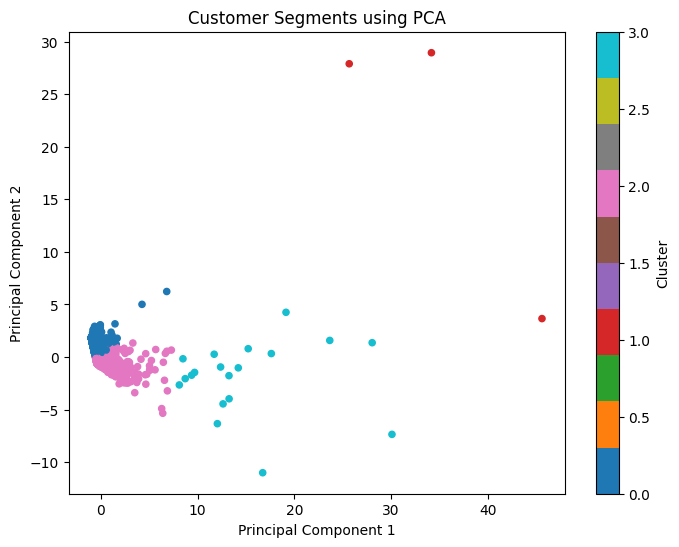

In [66]:
import matplotlib.pyplot as plt

# Save PCA coordinates in the dataframe
rfm["PC1"] = X_pca[:, 0]
rfm["PC2"] = X_pca[:, 1]

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    rfm["PC1"],
    rfm["PC2"],
    c=rfm["Cluster"],
    cmap="tab10",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [68]:
import joblib
import os

feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "TotalQuantity",
    "Country"
]

os.makedirs("models", exist_ok=True)

joblib.dump(kmeans, "models/clustering_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(pca, "models/pca.pkl")
joblib.dump(feature_columns, "models/feature_columns.pkl")

['models/feature_columns.pkl']

In [69]:
# Save final dataset with PCA coordinates and segment names
rfm.to_csv("segmented_customers.csv", index=False)

print("segmented_customers.csv saved successfully.")

segmented_customers.csv saved successfully.


In [70]:
import shutil

shutil.make_archive("models", "zip", "models")
print("models.zip created.")

models.zip created.


In [71]:
from google.colab import files

files.download("models.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
from google.colab import files
files.download("segmented_customers.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>